In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_curve, roc_auc_score,
                             accuracy_score, precision_score, recall_score)

In [89]:
data=pd.read_csv(r"C:\Users\myjyu\Downloads\cs-training.csv\cs-training.csv")

In [90]:
data.head(10)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
5,6,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0
6,7,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0
7,8,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0.0
8,9,0,0.116951,27,0,46.000000,NaN,2,0,0,0,NaN
9,10,0,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0


In [91]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [92]:
data = data.drop("Unnamed: 0", axis=1)


In [93]:
data.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [94]:
data.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [95]:
data["MonthlyIncome"]=data['MonthlyIncome'].fillna(data['MonthlyIncome'].median(),inplace=True)

C:\Users\myjyu\AppData\Local\Temp\ipykernel_20884\3262263735.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data["MonthlyIncome"]=data['MonthlyIncome'].fillna(data['MonthlyIncome'].median(),inplace=True)


In [96]:
data["NumberOfDependents"]=data["NumberOfDependents"].fillna(data["NumberOfDependents"].mode()[0],inplace=True)

C:\Users\myjyu\AppData\Local\Temp\ipykernel_20884\3826229666.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data["NumberOfDependents"]=data["NumberOfDependents"].fillna(data["NumberOfDependents"].mode()[0],inplace=True)


In [97]:
data.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [98]:
data.duplicated().sum()

np.int64(767)

Text(0.5, 1.0, 'Target Distrubution SeriousDlqin2yrs')

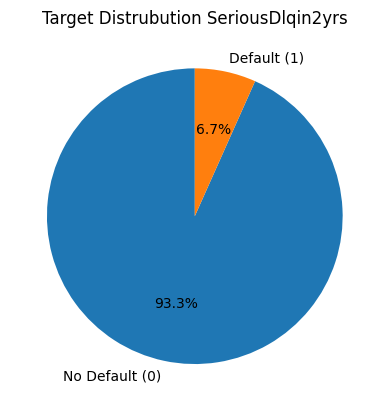

In [99]:
plt.Figure(figsize=(8,6))
data["SeriousDlqin2yrs"].value_counts().plot.pie(labels=["No Default (0)", "Default (1)"],startangle=90,autopct="%1.1f%%")
plt.title("Target Distrubution SeriousDlqin2yrs")


Text(0.5, 1.0, 'Monthly Income Distribution — Defaulters Only')

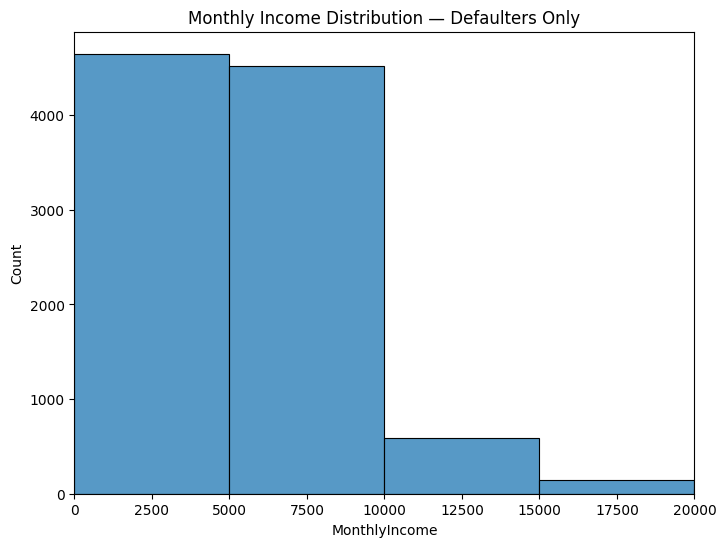

In [100]:
plt.figure(figsize=(8,6))
sns.histplot(data=data,x=data[data["SeriousDlqin2yrs"]==1]["MonthlyIncome"],edgecolor="Black",bins=50)
plt.xlim(0, 20000)
plt.title("Monthly Income Distribution — Defaulters Only")

C:\Users\myjyu\AppData\Local\Temp\ipykernel_20884\22262832.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="SeriousDlqin2yrs", y='age', palette='Set2')


Text(0, 0.5, 'Age')

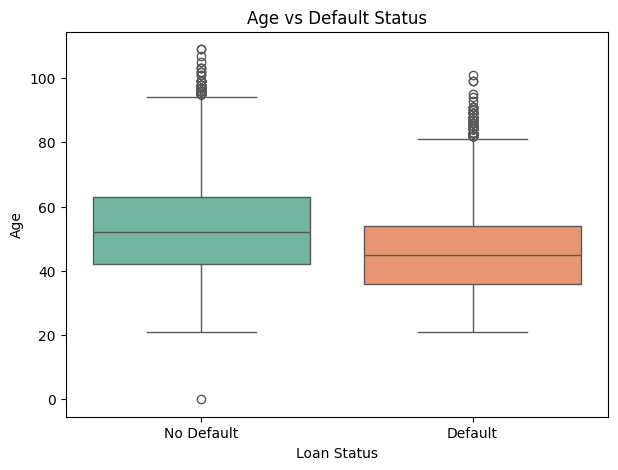

In [101]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=data, x="SeriousDlqin2yrs", y='age', palette='Set2')
plt.title("Age vs Default Status")
plt.xticks([0, 1], ['No Default', 'Default'])
plt.xlabel("Loan Status")
plt.ylabel("Age")

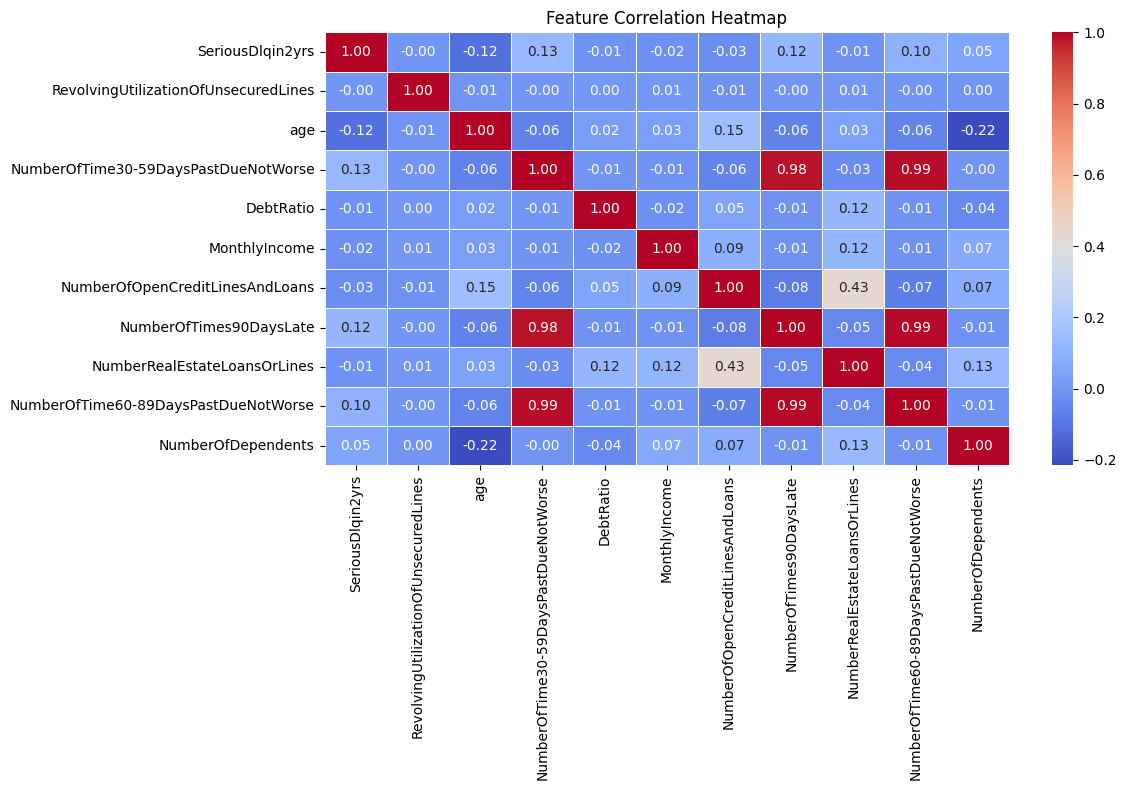

In [102]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(),annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


In [134]:
x=data.drop("SeriousDlqin2yrs",axis=1)
y=data["SeriousDlqin2yrs"]

In [135]:
x.shape

(150000, 10)

In [105]:
y.shape

(150000,)

In [106]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)
scaler=StandardScaler()
x_scaler_train=scaler.fit_transform(x_train)
x_scaler_test=scaler.transform(x_test)

In [107]:
x_scaler_train.shape

(120000, 10)

In [108]:
x_scaler_test.shape

(30000, 10)

In [109]:
smote = SMOTE(random_state=42)
x_train_sm, y_train_sm = smote.fit_resample(x_scaler_train, y_train)


In [110]:
model=RandomForestClassifier(n_estimators=100,max_depth=10,class_weight='balanced',random_state=42)
model.fit(x_train_sm, y_train_sm)
y_pred=model.predict(x_scaler_test)
y_prob=model.predict_proba(x_scaler_test)[:, 1]

In [111]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(30000,))

In [112]:
y_prob

array([0.03379023, 0.03802329, 0.04527152, ..., 0.46971528, 0.04443621,
       0.0625991 ], shape=(30000,))

In [113]:
c=confusion_matrix(y_test,y_pred)
c

array([[24169,  3875],
       [  657,  1299]])

In [114]:
print("precision = ",(precision_score(y_test,y_pred)))
print("Recall Score = ",(recall_score(y_test,y_pred)))
print("F1 Score = ",(f1_score(y_test,y_pred)))
print("Accuracy = ",(accuracy_score(y_test,y_pred)))
print("Auc = ",(roc_auc_score(y_test,y_prob)))

precision =  0.2510630073444144
Recall Score =  0.6641104294478528
F1 Score =  0.3643758765778401
Accuracy =  0.8489333333333333
Auc =  0.8546661100625105


Text(0.5, 1.0, 'Actual Default Data vs Pridicted Data')

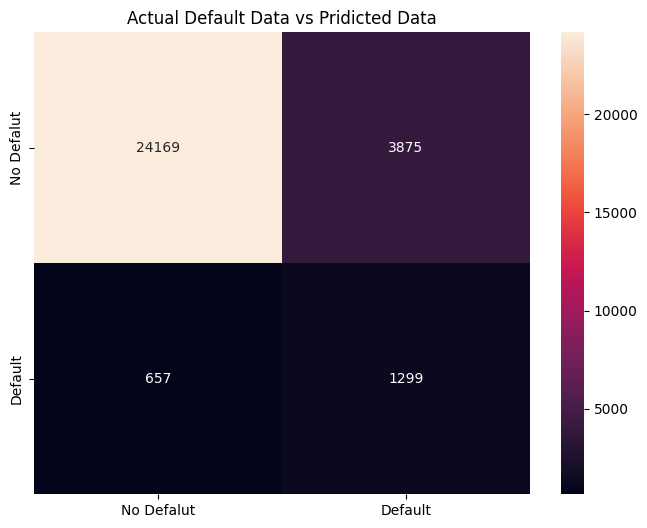

In [115]:
plt.figure(figsize=(8,6))
sns.heatmap(c,annot=True,fmt='d',xticklabels=['No Defalut','Default'],yticklabels=['No Defalut','Default'])
plt.title("Actual Default Data vs Pridicted Data")

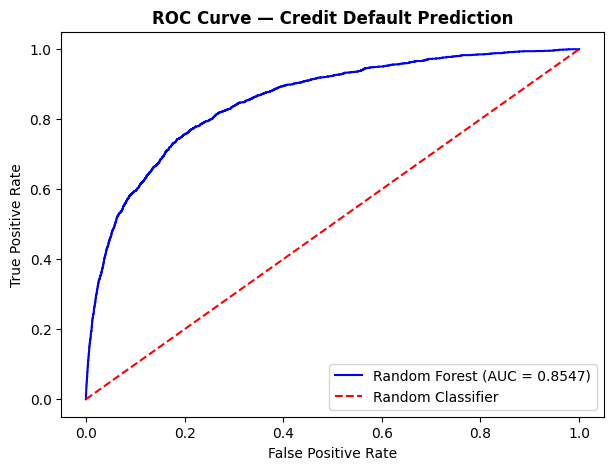

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
auc_value = auc(fpr, tpr) 
plt.plot(fpr,tpr, color='blue',label=f'Random Forest (AUC = {auc_value:.4f})')
plt.plot([0, 1], [0, 1], 'r--',label='Random Classifier')
plt.title("ROC Curve — Credit Default Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

C:\Users\myjyu\AppData\Local\Temp\ipykernel_20884\2556865264.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( data=importent_data,y='features', x='importent', palette='viridis')


Text(0.5, 1.0, 'Feature Importance — Credit Default Prediction')

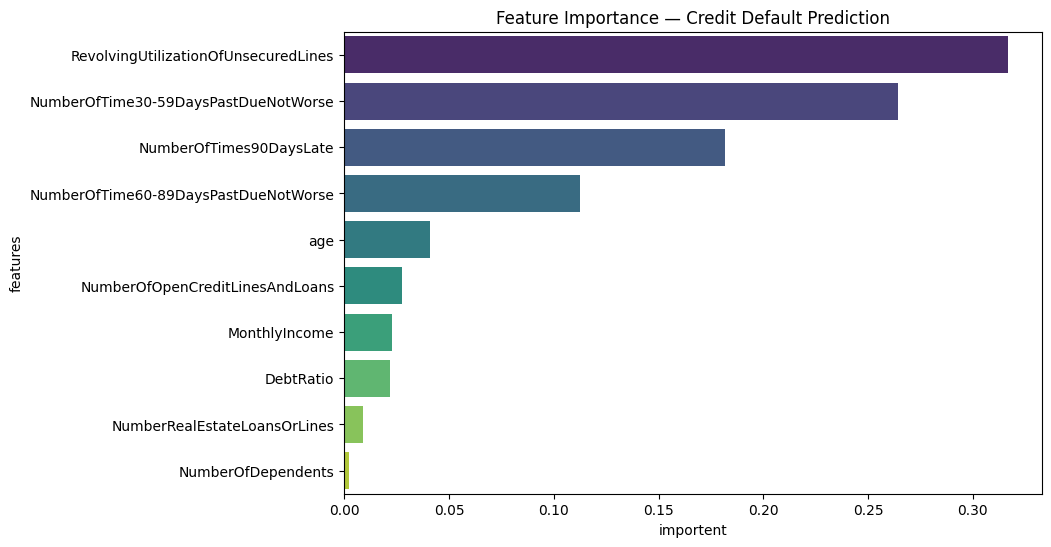

In [148]:
importent_data=pd.DataFrame({'features':x.columns,'importent':model.feature_importances_})
importent_data=importent_data.sort_values(by='importent',ascending=False)
plt.figure(figsize=(9, 6))
sns.barplot( data=importent_data,y='features', x='importent', palette='viridis')
plt.title("Feature Importance — Credit Default Prediction")